In [14]:
import os
import getdist
from getdist import MCSamples, plots
import numpy as np
from tensiometer import gaussian_tension
from scipy import stats

# DEFINIR LAS RUTAS
# Para Planck, usamos la RAÍZ (sin .txt) porque son múltiples archivos
ruta_planck = r"C:\Users\hijos\Investigacion 1\Planck\base\plikHM_TTTEEE_lowl_lowE_lensing\base_plikHM_TTTEEE_lowl_lowE_lensing"

# Para Pantheon, usamos EL ARCHIVO EXACTO porque es un único archivo CosmoSIS
archivo_pantheon = r"C:\Users\hijos\Investigacion 1\Pantheon+SH0ES_LambdaCDM.txt"

cadena_DES = r"C:\Users\hijos\Investigacion 1\multimeter\chains\cadena_des_shoes.txt"

data_union = r"C:\Users\hijos\Investigacion 1\multimeter\chains\cadenas_MCMC_parche.txt"

print("Cargando la cadena de Planck...")
chain_planck = getdist.mcsamples.loadMCSamples(ruta_planck, settings={'ignore_rows': 0.3})

# CARGAR PANTHEON (Modo Manual para CosmoSIS)

print("Cargando la cadena de Pantheon...")
datos_pantheon_crudos = np.loadtxt(archivo_pantheon, comments='#')

# Cortamos el primer 30% como "burn-in" 
burn_in = int(0.3 * len(datos_pantheon_crudos))
datos_pantheon_limpios = datos_pantheon_crudos[burn_in:]

# Según el doc:
# Columna 0 es omega_m
# Columna 1 es H0
# Extraemos solo esas dos columnas y las juntamos

col_omega_m = datos_pantheon_limpios[:, 0]

#Multiplicamos por 100 para convertir 'h' en 'H0'
col_H0 = datos_pantheon_limpios[:, 1] * 100 

# Las juntamos
muestras_pantheon = np.column_stack((col_H0, col_omega_m))


# Creamos el objeto MCSamples manualmente. 
# Le damos los MISMOS nombres que usa Planck ('H0' y 'omegam') para poder compararlos.
chain_pantheon = MCSamples(samples=muestras_pantheon, 
                           names=['H0', 'omegam'], 
                           labels=['H_0', r'\Omega_m'])
chain_pantheon.updateSettings({'smooth_scale_2D': 0.5}) 


# --- CARGAR LA CADENA DES (Modo Manual para TXT simple) ---

print("Cargando la cadena de DES...")

# 1. Cargamos los datos saltando la primera fila (skiprows=1) para ignorar el texto "Om H0 M_offset"
datos_des_crudos = np.loadtxt(cadena_DES, skiprows=1)

# 2. Extraemos las columnas que nos interesan
# Columna 0 es Om (omega_m)
# Columna 1 es H0
col_omega_m_des = datos_des_crudos[:, 0]
col_H0_des = datos_des_crudos[:, 1]

# 3. Las juntamos en el mismo orden que las otras cadenas (H0, omegam)
muestras_des = np.column_stack((col_H0_des, col_omega_m_des))

# 4. Sobrescribimos el objeto MCSamples asegurando que los nombres coincidan exactamente
chain_DES = MCSamples(samples=muestras_des, 
                      names=['H0', 'omegam'], 
                      labels=['H_0', r'\Omega_m'],
                      name_tag='DES')
chain_DES.updateSettings({'smooth_scale_2D': 0.5})


datos_union_crudos = np.loadtxt(data_union, skiprows=1)
col_omega_m_union = datos_union_crudos[:, 0]
col_H0_union = datos_union_crudos[:, 1]

muestras_union = np.column_stack((col_H0_union, col_omega_m_union))
chain_union = MCSamples(samples=muestras_union, 
                      names=['H0', 'omegam'], 
                      labels=['H_0', r'\Omega_m'],
                      name_tag='Union3')
chain_union.updateSettings({'smooth_scale_2D': 0.5})

print("Datasets cargados exitosamente!")

# Verificación final de parámetros
print("\nParámetros en Planck:", chain_planck.getParamNames().list())
print("Parámetros en Pantheon:", chain_pantheon.getParamNames().list())
print("Parámetros en DES:", chain_DES.getParamNames().list())
print("Parámetros en Union3:", chain_union.getParamNames().list())

Cargando la cadena de Planck...
Cargando la cadena de Pantheon...
Removed no burn in
Cargando la cadena de DES...
Removed no burn in
Removed no burn in
Datasets cargados exitosamente!

Parámetros en Planck: ['omegabh2', 'omegach2', 'theta', 'tau', 'logA', 'ns', 'calPlanck', 'acib217', 'xi', 'asz143', 'aps100', 'aps143', 'aps143217', 'aps217', 'aksz', 'kgal100', 'kgal143', 'kgal143217', 'kgal217', 'galfTE100', 'galfTE100143', 'galfTE100217', 'galfTE143', 'galfTE143217', 'galfTE217', 'cal0', 'cal2', 'H0', 'omegal', 'omegam', 'omegamh2', 'omegamh3', 'sigma8', 'S8', 's8omegamp5', 's8omegamp25', 's8h5', 'rdragh', 'rmsdeflect', 'zrei', 'A', 'clamp', 'DL40', 'DL220', 'DL810', 'DL1420', 'DL2000', 'ns02', 'yheused', 'YpBBN', 'DHBBN', 'age', 'zstar', 'rstar', 'thetastar', 'DAstar', 'zdrag', 'rdrag', 'kd', 'thetad', 'zeq', 'keq', 'thetaeq', 'thetarseq', 'Hubble015', 'DM015', 'Hubble038', 'DM038', 'Hubble051', 'DM051', 'Hubble061', 'DM061', 'Hubble233', 'DM233', 'fsigma8z015', 'sigma8z015', 'fsigm

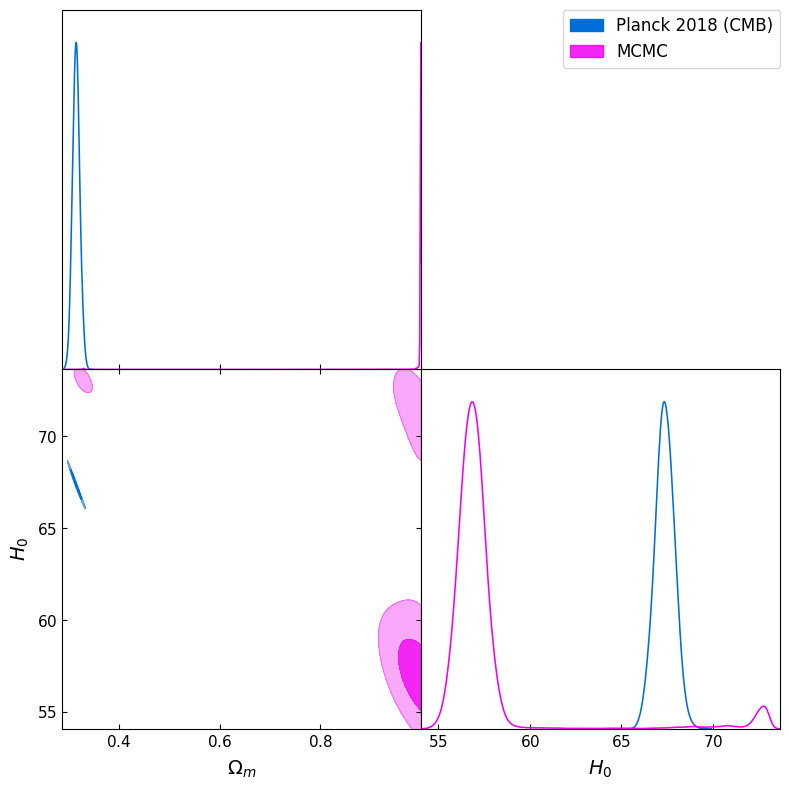

In [16]:
import matplotlib.pyplot as plt

#Queremos comparar H0 y omegam
parametros_a_graficar = ['omegam', 'H0']

#figura
g = plots.get_subplot_plotter(width_inch=8)

# Creamos el gráfico ocupando ambas cadenas
g.triangle_plot([chain_planck, chain_union], 
                parametros_a_graficar, 
                filled=True, 
                legend_labels=['Planck 2018 (CMB)', 'MCMC'],
                contour_colors=["#006DD9FF", "#F300F3"]) # Azul (Planck) y Morado (Union3)

#plt.suptitle('Tensión de Hubble: CMB vs SNe ', fontsize=16, y =1.02)
plt.show()

In [9]:
import os
import getdist
from getdist import MCSamples, plots
import numpy as np
from tensiometer import gaussian_tension
from scipy import stats

# DEFINIR LAS RUTAS
# Para Planck, usamos la RAÍZ (sin .txt) porque son múltiples archivos
ruta_planck = r"C:\Users\hijos\Investigacion 1\Planck\base\plikHM_TTTEEE_lowl_lowE_lensing\base_plikHM_TTTEEE_lowl_lowE_lensing"

# Para Pantheon, usamos EL ARCHIVO EXACTO porque es un único archivo CosmoSIS
archivo_pantheon = r"C:\Users\hijos\Investigacion 1\Pantheon+SH0ES_LambdaCDM.txt"

cadena_DES = r"C:\Users\hijos\Investigacion 1\multimeter\chains\cadena_des_shoes.txt"

data_union = r"C:\Users\hijos\Investigacion 1\multimeter\chains\cadena_des_shoes_v2.txt"

data_union_planck = r"C:\Users\hijos\Investigacion 1\multimeter\chains\cadena_union3_planck.txt"
print("Cargando la cadena de Planck...")
chain_planck = getdist.mcsamples.loadMCSamples(ruta_planck, settings={'ignore_rows': 0.3})


datos_union_crudos = np.loadtxt(data_union, skiprows=1)
col_omega_m_union = datos_union_crudos[:, 0]
col_H0_union = datos_union_crudos[:, 1]

muestras_union = np.column_stack((col_H0_union, col_omega_m_union))
chain_union = MCSamples(samples=muestras_union, 
                      names=['H0', 'omegam'], 
                      labels=['H_0', r'\Omega_m'],
                      name_tag='Union3')
chain_union.updateSettings({'smooth_scale_2D': 0.5})



datos_union_planck_crudos = np.loadtxt(data_union_planck, skiprows=1)
col_omega_m_union_planck = datos_union_planck_crudos[:, 0]
col_H0_union_planck = datos_union_planck_crudos[:, 1]

muestras_union_planck = np.column_stack((col_H0_union_planck, col_omega_m_union_planck))
chain_union_planck = MCSamples(samples=muestras_union_planck, 
                              names=['H0', 'omegam'], 
                              labels=['H_0', r'\Omega_m'],
                              name_tag='Union3_Planck')
chain_union_planck.updateSettings({'smooth_scale_2D': 0.5})

print("Datasets cargados exitosamente!")

# Verificación final de parámetros
print("\nParámetros en Planck:", chain_planck.getParamNames().list())

print("Parámetros en Union3:", chain_union.getParamNames().list())
print("Parámetros en Union3_Planck:", chain_union_planck.getParamNames().list())



Cargando la cadena de Planck...
Removed no burn in
Removed no burn in
Datasets cargados exitosamente!

Parámetros en Planck: ['omegabh2', 'omegach2', 'theta', 'tau', 'logA', 'ns', 'calPlanck', 'acib217', 'xi', 'asz143', 'aps100', 'aps143', 'aps143217', 'aps217', 'aksz', 'kgal100', 'kgal143', 'kgal143217', 'kgal217', 'galfTE100', 'galfTE100143', 'galfTE100217', 'galfTE143', 'galfTE143217', 'galfTE217', 'cal0', 'cal2', 'H0', 'omegal', 'omegam', 'omegamh2', 'omegamh3', 'sigma8', 'S8', 's8omegamp5', 's8omegamp25', 's8h5', 'rdragh', 'rmsdeflect', 'zrei', 'A', 'clamp', 'DL40', 'DL220', 'DL810', 'DL1420', 'DL2000', 'ns02', 'yheused', 'YpBBN', 'DHBBN', 'age', 'zstar', 'rstar', 'thetastar', 'DAstar', 'zdrag', 'rdrag', 'kd', 'thetad', 'zeq', 'keq', 'thetaeq', 'thetarseq', 'Hubble015', 'DM015', 'Hubble038', 'DM038', 'Hubble051', 'DM051', 'Hubble061', 'DM061', 'Hubble233', 'DM233', 'fsigma8z015', 'sigma8z015', 'fsigma8z038', 'sigma8z038', 'fsigma8z051', 'sigma8z051', 'fsigma8z061', 'sigma8z061', '

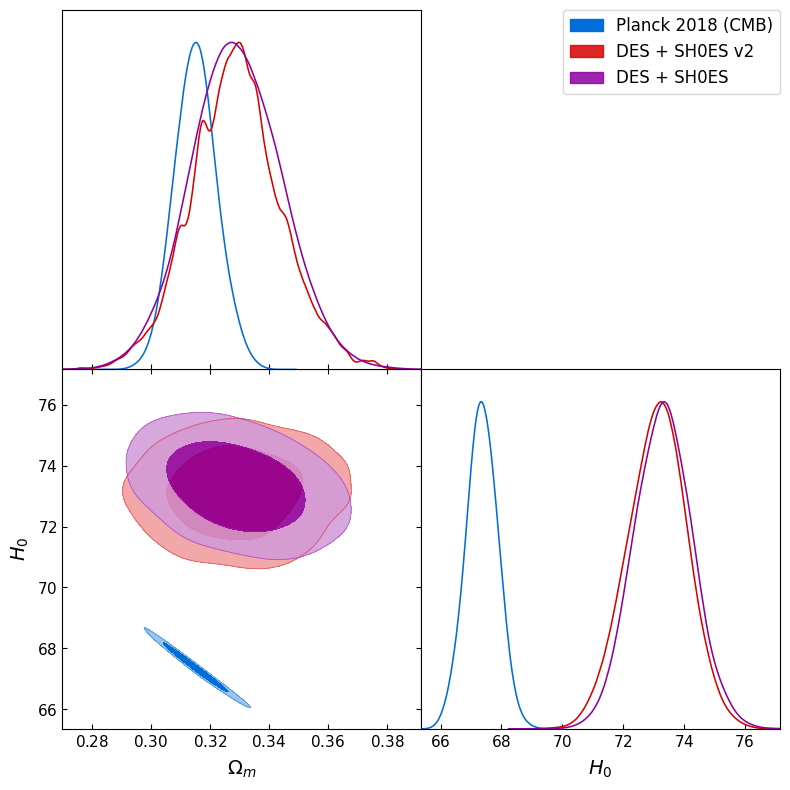

In [13]:
#Queremos comparar H0 y omegam
parametros_a_graficar = ['omegam', 'H0']

#figura
g = plots.get_subplot_plotter(width_inch=8)

# Creamos el gráfico ocupando ambas cadenas
g.triangle_plot([chain_planck, chain_DES, chain_union], 
                parametros_a_graficar, 
                filled=True, 
                legend_labels=['Planck 2018 (CMB)', 'DES + SH0ES v2', 'DES + SH0ES'],
                contour_colors=["#006DD9FF", '#D90000', "#8D00A0"]) # Azul (Planck), Rojo (Pantheon), Verde (DES) y Morado (Union3)

#plt.suptitle('Tensión de Hubble: CMB vs SNe ', fontsize=16, y =1.02)
plt.show()

In [11]:
import os
import getdist
from getdist import MCSamples, plots
import numpy as np
from tensiometer import gaussian_tension
from scipy import stats

# DEFINIR LAS RUTAS
# Para Planck, usamos la RAÍZ (sin .txt) porque son múltiples archivos
ruta_planck = r"C:\Users\hijos\Investigacion 1\Planck\base\plikHM_TTTEEE_lowl_lowE_lensing\base_plikHM_TTTEEE_lowl_lowE_lensing"


cadena_DES = r"C:\Users\hijos\Investigacion 1\multimeter\chains\cadena_des_shoes.txt"

cadena_DES_planck = r"C:\Users\hijos\Investigacion 1\multimeter\chains\cadena_des_planck.txt"



print("Cargando la cadena de Planck...")
chain_planck = getdist.mcsamples.loadMCSamples(ruta_planck, settings={'ignore_rows': 0.3})


datos_DES_crudos = np.loadtxt(cadena_DES, skiprows=1)
col_omega_m_DES = datos_DES_crudos[:, 0]
col_H0_DES = datos_DES_crudos[:, 1]

muestras_DES = np.column_stack((col_H0_DES, col_omega_m_DES))
chain_DES = MCSamples(samples=muestras_DES, 
                      names=['H0', 'omegam'], 
                      labels=['H_0', r'\Omega_m'],
                      name_tag='Union3')
chain_DES.updateSettings({'smooth_scale_2D': 0.5})



datos_DES_planck_crudos = np.loadtxt(cadena_DES_planck, skiprows=1)
col_omega_m_DES_planck = datos_DES_planck_crudos[:, 0]
col_H0_DES_planck = datos_DES_planck_crudos[:, 1]

muestras_DES_planck = np.column_stack((col_H0_DES_planck, col_omega_m_DES_planck))
chain_DES_planck = MCSamples(samples=muestras_DES_planck, 
                              names=['H0', 'omegam'], 
                              labels=['H_0', r'\Omega_m'],
                              name_tag='Union3_Planck')
chain_DES_planck.updateSettings({'smooth_scale_2D': 0.5})

print("Datasets cargados exitosamente!")

# Verificación final de parámetros
print("\nParámetros en Planck:", chain_planck.getParamNames().list())

print("Parámetros en DES:", chain_DES.getParamNames().list())
print("Parámetros en DES_Planck:", chain_DES_planck.getParamNames().list())



Cargando la cadena de Planck...
Removed no burn in
Removed no burn in
Datasets cargados exitosamente!

Parámetros en Planck: ['omegabh2', 'omegach2', 'theta', 'tau', 'logA', 'ns', 'calPlanck', 'acib217', 'xi', 'asz143', 'aps100', 'aps143', 'aps143217', 'aps217', 'aksz', 'kgal100', 'kgal143', 'kgal143217', 'kgal217', 'galfTE100', 'galfTE100143', 'galfTE100217', 'galfTE143', 'galfTE143217', 'galfTE217', 'cal0', 'cal2', 'H0', 'omegal', 'omegam', 'omegamh2', 'omegamh3', 'sigma8', 'S8', 's8omegamp5', 's8omegamp25', 's8h5', 'rdragh', 'rmsdeflect', 'zrei', 'A', 'clamp', 'DL40', 'DL220', 'DL810', 'DL1420', 'DL2000', 'ns02', 'yheused', 'YpBBN', 'DHBBN', 'age', 'zstar', 'rstar', 'thetastar', 'DAstar', 'zdrag', 'rdrag', 'kd', 'thetad', 'zeq', 'keq', 'thetaeq', 'thetarseq', 'Hubble015', 'DM015', 'Hubble038', 'DM038', 'Hubble051', 'DM051', 'Hubble061', 'DM061', 'Hubble233', 'DM233', 'fsigma8z015', 'sigma8z015', 'fsigma8z038', 'sigma8z038', 'fsigma8z051', 'sigma8z051', 'fsigma8z061', 'sigma8z061', '

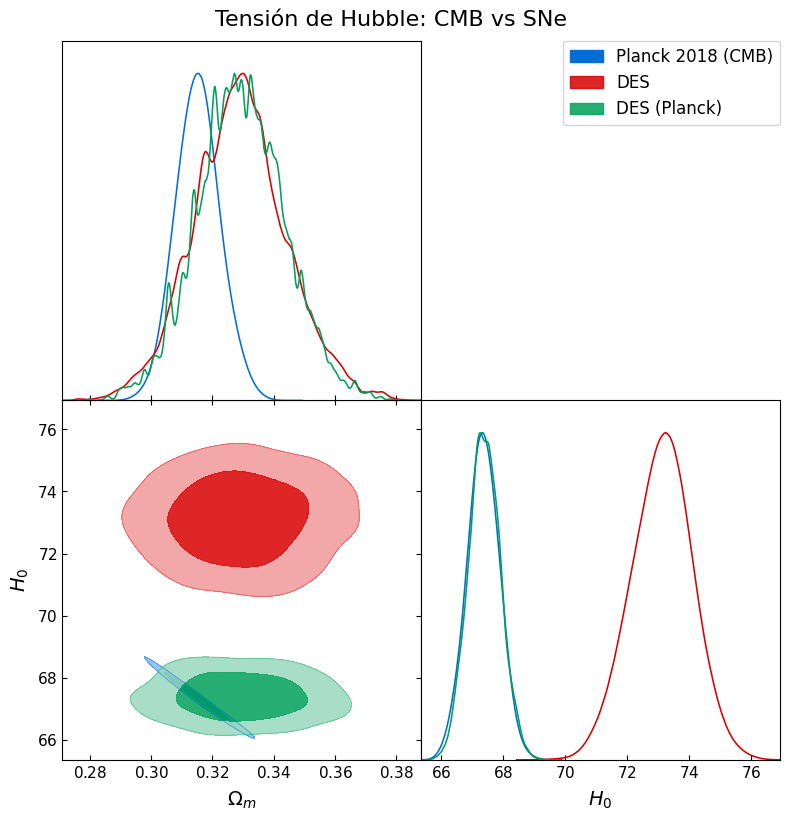

In [12]:
#Queremos comparar H0 y omegam
parametros_a_graficar = ['omegam', 'H0']

#figura
g = plots.get_subplot_plotter(width_inch=8)

# Creamos el gráfico ocupando ambas cadenas
g.triangle_plot([chain_planck, chain_DES, chain_DES_planck], 
                parametros_a_graficar, 
                filled=True, 
                legend_labels=['Planck 2018 (CMB)', 'DES', 'DES (Planck)'],
                contour_colors=["#006DD9FF", '#D90000', '#00A05A']) # Azul (Planck), Rojo (Pantheon), Verde (DES) y Morado (Union3)

plt.suptitle('Tensión de Hubble: CMB vs SNe ', fontsize=16, y =1.02)
plt.show()